# **Environment Setup & Imports**

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

2026-05-15 04:39:04.347283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778819944.796450      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778819944.913343      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778819945.923171      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778819945.923233      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778819945.923236      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Keras Version: 3.10.0


# **DeepLabV3+ Model Architecture**

In [2]:
def ConvolutionBlock(block_input, num_filters, kernel_size=3, dilation_rate=1, padding="same"):
    x = layers.Conv2D(num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding=padding, use_bias=False)(block_input)
    x = layers.BatchNormalization()(x)
    return layers.ReLU()(x) # Fixed: Using Keras layer instead of tf.nn

def DilatedSpatialPyramidPooling(dspp_input):
    dims = dspp_input.shape
    # Standard 1x1 conv
    out_1 = ConvolutionBlock(dspp_input, 256, kernel_size=1)
    # Dilated convs for different scales
    out_6 = ConvolutionBlock(dspp_input, 256, dilation_rate=6)
    out_12 = ConvolutionBlock(dspp_input, 256, dilation_rate=12)
    out_18 = ConvolutionBlock(dspp_input, 256, dilation_rate=18)
    
    # Global average pooling
    image_features = layers.GlobalAveragePooling2D()(dspp_input)
    image_features = layers.Reshape((1, 1, dims[-1]))(image_features)
    image_features = ConvolutionBlock(image_features, 256, kernel_size=1)
    image_features = layers.UpSampling2D(size=(dims[1], dims[2]), interpolation="bilinear")(image_features)

    x = layers.Concatenate(axis=-1)([image_features, out_1, out_6, out_12, out_18])
    return ConvolutionBlock(x, 256, kernel_size=1)

def DeeplabV3Plus(image_size, num_classes):
    model_input = keras.Input(shape=(image_size, image_size, 3))
    
    # Pre-trained MobileNetV2 Backbone
    backbone = keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_tensor=model_input)
    
    # Encoder part
    x = backbone.get_layer("block_13_expand_relu").output 
    x = DilatedSpatialPyramidPooling(x)
    
    # Decoder part
    input_a = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    input_b = backbone.get_layer("block_3_expand_relu").output
    input_b = ConvolutionBlock(input_b, 48, kernel_size=1)

    x = layers.Concatenate(axis=-1)([input_a, input_b])
    x = ConvolutionBlock(x, 256)
    x = ConvolutionBlock(x, 256)
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    
    # Output layer
    model_output = layers.Conv2D(num_classes, kernel_size=(1, 1), padding="same")(x)
    return keras.Model(inputs=model_input, outputs=model_output)

# Create the model
IMAGE_SIZE = 512
NUM_CLASSES = 3 # 0:Background, 1:Wall, 2:Floor
model = DeeplabV3Plus(image_size=IMAGE_SIZE, num_classes=NUM_CLASSES)
model.summary()

/tmp/ipykernel_57/3142773362.py:28: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_tensor=model_input)
I0000 00:00:1778819986.683174      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778819986.689187      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 256, 256,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 256, 256,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 256, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 256, 256,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 256, 256,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 256, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 257, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 128, 128,  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 128, 128,  │      2,304 │ block_1_depthwis

 Total params: 6,526,467 (24.90 MB)

 Trainable params: 6,504,995 (24.81 MB)

 Non-trainable params: 21,472 (83.88 KB)

# **Training Configuration (Loss & Optimizer)**

In [3]:
# We use SparseCategoricalCrossentropy because our labels are integers (0, 1, 2)
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
    loss=loss_fn, 
    metrics=["accuracy"]
)

print("✅ Training Configuration Complete.")

✅ Training Configuration Complete.


# **Accuracy Evaluation (mIoU)**

In [4]:
# Mean Intersection over Union (mIoU) is the best metric for Segmentation
miou_metric = keras.metrics.MeanIoU(num_classes=NUM_CLASSES)

print("✅ Accuracy Metric (mIoU) Initialized.")

✅ Accuracy Metric (mIoU) Initialized.



# **Find My Files**

In [5]:
import os
# This prints every folder in your Kaggle input
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'training' in dirname and len(filenames) > 0:
        print(f"📂 Found images at: {dirname}")
        print(f"📄 Sample file: {filenames[0]}")
        break

📂 Found images at: /kaggle/input/datasets/ipythonx/ade20k-scene-parsing/ADEChallengeData2016/annotations/training
📄 Sample file: ADE_train_00010743.png


# **Dataset Preparation (ADE20K Subset)**

In [8]:
import os
import glob
import tensorflow as tf

# 1. AUTO-SCAN FOR THE FOLDERS
print("🔄 Scanning Kaggle inputs for ADE20K folders...")
img_dirs = glob.glob("/kaggle/input/**/images/training/", recursive=True)
msk_dirs = glob.glob("/kaggle/input/**/annotations/training/", recursive=True)

if not img_dirs or not msk_dirs:
    # If the above fails, let's look for any 'training' folder
    img_dirs = glob.glob("/kaggle/input/**/training/", recursive=True)
    # We will pick the one that contains .jpg files for images
    IMG_DIR = ""
    MSK_DIR = ""
    for d in img_dirs:
        if any(f.endswith('.jpg') for f in os.listdir(d)):
            IMG_DIR = d
        elif any(f.endswith('.png') for f in os.listdir(d)):
            MSK_DIR = d
else:
    IMG_DIR = img_dirs[0]
    MSK_DIR = msk_dirs[0]

print(f"📍 Image Directory: {IMG_DIR}")
print(f"📍 Mask Directory: {MSK_DIR}")

# 2. MATCH IMAGES WITH MASKS
all_images = sorted([os.path.join(IMG_DIR, f) for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
all_masks = sorted([os.path.join(MSK_DIR, f) for f in os.listdir(MSK_DIR) if f.endswith('.png')])

print(f"🔍 Found {len(all_images)} images.")
print(f"🔍 Found {len(all_masks)} masks.")

# 3. PROCEED ONLY IF FOUND
if len(all_images) > 0 and len(all_masks) > 0:
    NUM_SAMPLES = min(2000, len(all_images))
    valid_images = all_images[:NUM_SAMPLES]
    valid_masks = all_masks[:NUM_SAMPLES]

    split = int(len(valid_images) * 0.9)
    train_images, val_images = valid_images[:split], valid_images[split:]
    train_masks, val_masks = valid_masks[:split], valid_masks[split:]

    def load_data(image_path, mask_path):
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
        image = tf.cast(image, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, [IMAGE_SIZE, IMAGE_SIZE], method="nearest")
        
        wall_mask = tf.cast(tf.equal(mask, 1), tf.int32)
        floor_mask = tf.cast(tf.equal(mask, 4), tf.int32) * 2
        final_mask = wall_mask + floor_mask
        
        return image, final_mask

    def prepare_dataset(imgs, msks):
        ds = tf.data.Dataset.from_tensor_slices((imgs, msks))
        ds = ds.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(4).shuffle(100).prefetch(tf.data.AUTOTUNE)
        return ds

    train_dataset = prepare_dataset(train_images, train_masks)
    val_dataset = prepare_dataset(val_images, val_masks)
    print(f"✅ Setup Complete! Ready to train.")
else:
    print("❌ ERROR: Could not locate the files. Please ensure the ADE20K dataset is correctly added.")

🔄 Scanning Kaggle inputs for ADE20K folders...
📍 Image Directory: /kaggle/input/datasets/ipythonx/ade20k-scene-parsing/ADEChallengeData2016/images/training/
📍 Mask Directory: /kaggle/input/datasets/ipythonx/ade20k-scene-parsing/ADEChallengeData2016/annotations/training/
🔍 Found 20210 images.
🔍 Found 20210 masks.
✅ Setup Complete! Ready to train.


# **The Training Loop**

In [10]:
EPOCHS = 20 

history = model.fit(
    train_dataset,        # Changed from 'dataset' to 'train_dataset'
    validation_data=val_dataset, # This will show you real-time accuracy!
    epochs=EPOCHS,
    verbose=1
)

# Save the trained model weights
model.save("ar_homeviz_wall_model_v1.keras")
print("✅ Training Complete. Model saved as ar_homeviz_wall_model_v1.keras")

Epoch 1/20


I0000 00:00:1778820396.169778     132 service.cc:152] XLA service 0x7aa568003340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778820396.169822     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778820396.169827     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778820399.965324     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 04:46:49.073108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 04:46:49.210885: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 04:46:49.998063: E external/local_xl

450/450 ━━━━━━━━━━━━━━━━━━━━ 276s 439ms/step - accuracy: 0.7292 - loss: 0.6507 - val_accuracy: 0.6856 - val_loss: 0.6793
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 426ms/step - accuracy: 0.8060 - loss: 0.4539 - val_accuracy: 0.7097 - val_loss: 0.6617
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 425ms/step - accuracy: 0.8493 - loss: 0.3674 - val_accuracy: 0.7231 - val_loss: 0.6151
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 425ms/step - accuracy: 0.8802 - loss: 0.2986 - val_accuracy: 0.7228 - val_loss: 0.6159
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 425ms/step - accuracy: 0.9009 - loss: 0.2480 - val_accuracy: 0.7062 - val_loss: 0.6689
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 426ms/step - accuracy: 0.9167 - loss: 0.2085 - val_accuracy: 0.7461 - val_loss: 0.6195
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 426ms/step - accuracy: 0.9330 - loss: 0.1707 - val_accuracy: 0.7274 - val_loss: 0.6775
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 193s 426ms/step - accuracy: 0.9437 - loss: 0.14

# **Accuracy Visualization**

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


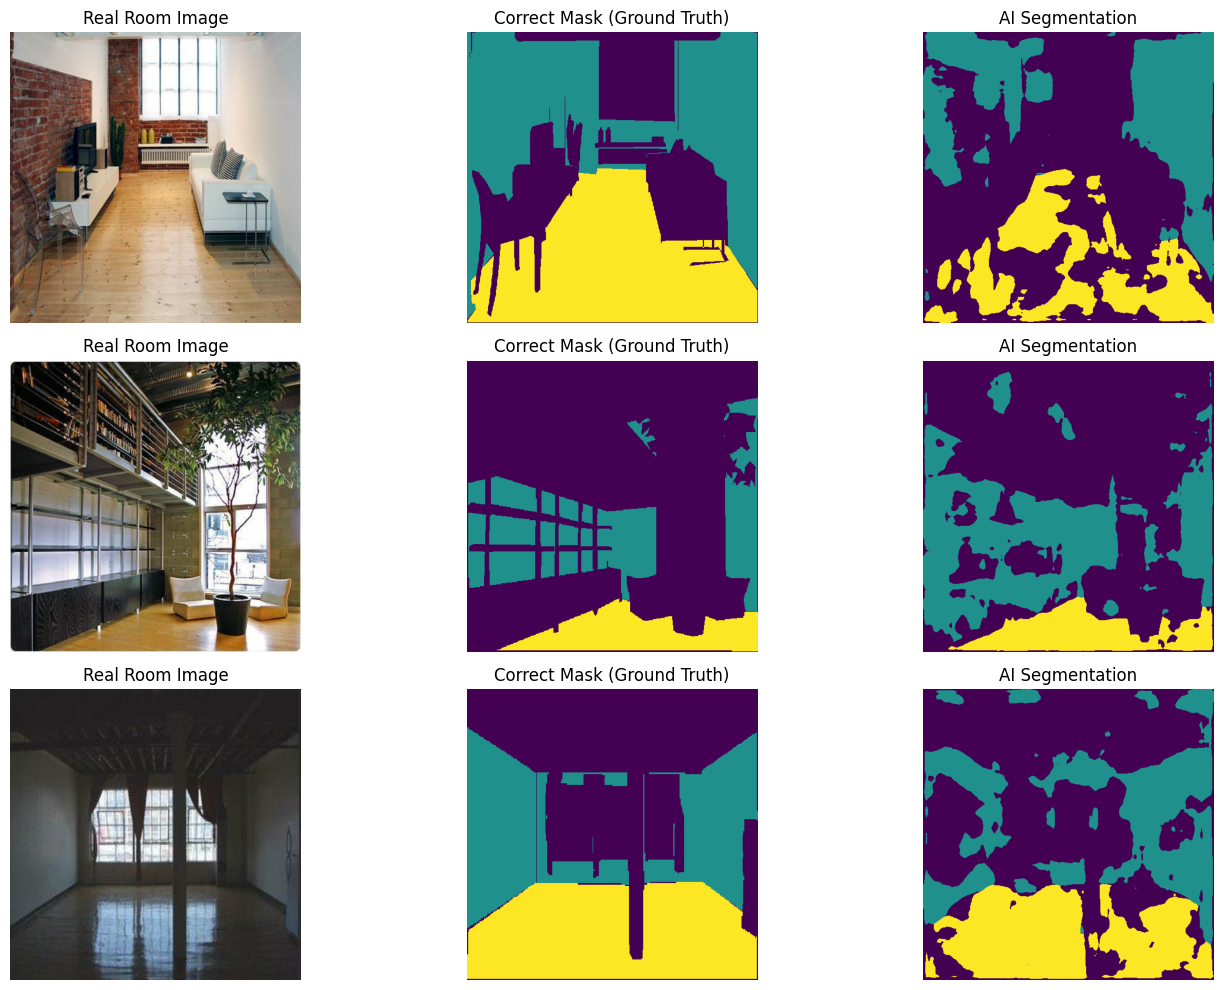

In [12]:
import matplotlib.pyplot as plt

def visualize_results(model, ds):
    # Get one batch from validation data
    images, masks = next(iter(ds))
    
    # AI makes a prediction
    preds = model.predict(images)
    preds = tf.argmax(preds, axis=-1)

    plt.figure(figsize=(15, 10))
    # Show the first 3 images from the batch
    for i in range(3):
        plt.subplot(3, 3, i*3 + 1)
        plt.title("Real Room Image")
        plt.imshow(images[i])
        plt.axis("off")
        
        plt.subplot(3, 3, i*3 + 2)
        plt.title("Correct Mask (Ground Truth)")
        plt.imshow(masks[i], vmin=0, vmax=2)
        plt.axis("off")
        
        plt.subplot(3, 3, i*3 + 3)
        plt.title("AI Segmentation")
        plt.imshow(preds[i], vmin=0, vmax=2)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Run visualization on validation data
visualize_results(model, val_dataset)

# **INT8 Quantization**

In [13]:
import tensorflow as tf

# 1. Convert the Keras model to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. Optimization: Full Integer Quantization
# This makes the model ~4x smaller and much faster on mobile
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# 3. Save the model
TFLITE_FILE = "deeplabv3_plus_wall.tflite"
with open(TFLITE_FILE, "wb") as f:
    f.write(tflite_model)

print(f"✅ SUCCESS! Model converted and saved as: {TFLITE_FILE}")
print(f"📦 Final Model Size: {os.path.getsize(TFLITE_FILE) / (1024*1024):.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmposlztpus/assets


INFO:tensorflow:Assets written to: /tmp/tmposlztpus/assets


Saved artifact at '/tmp/tmposlztpus'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name=None)
Captures:
  134854572129168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854567183952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854567184720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854572126864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854572130128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854572129744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854567184912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854567185680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854567185296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134854567184528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1348

W0000 00:00:1778824800.320826      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778824800.320895      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778824800.461358      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
